In [1]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from data_science_utilities.models.xgb.hyperparameter_search.random_search import OptimalXGBHyperparameterSearch

In [2]:
RANDOM_SEED = 32
BEST_NUM_FEATS = 32
TARGET = 'target_win'

RANDOM_XGB_PARAMS = {
    # How fast the model learns. The smaller, the more likely to get stuck in local minima, but the larger, the more likely to overshoot the global minima
    'learning_rate': [.03, .05, .1, .15, .2],
    # How deep the tree can be. The deeper, the more likely to overfit and more complex
    'max_depth': [2, 3],
    # The fraction of samples to be used for fitting the individual base learners. 
    # Values lower than 1 make the model more robust by preventing overfitting
    'subsample': [.5, .7, .9],
    # The minimum number of samples required to be at a leaf node. The larger, the more conservative
    'min_child_weight': [10, 20, 50, 100],
    # Minimum loss reduction required to make a split on a leaf node of the tree. Attempts to only split when it makes a significant improvement
    'gamma': [.5, 1, 5, 10, 100],
    # The number of trees to be used in the model. The more, the more likely to overfit
    'n_estimators': [10, 20,30, 40, 50],
    # The number of iterations the model can't improve before stopping
    'early_stopping_rounds': [10, 20, 50],
    # The way the model calculates the importance of each feature. Total gain is the sum of the gain of each feature used in the model
    'importance_type': ['total_gain'],
    # The evaluation metric to be used. AUC measures how well the model is able to distinguish between classes (win or loss)
    'eval_metric': ['auc']
}

RANDOM_SEARCH_PARAMS = dict(
    n_iter=100,
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    scoring='roc_auc',
)

BEST_FEATS_FROM_RFE = list(pd.read_csv(
    '../../../../../data/predict_games/model_features_in/rfe_features_kfolds.csv',
    index_col=0
).loc[BEST_NUM_FEATS, :].dropna().values)

MODEL_INPUTS_DF = pd.read_parquet(
    '../../../../../data/predict_games/input_data/schedule_and_weekly.parquet'
)

MODEL_INPUTS_DF = MODEL_INPUTS_DF.sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)

np.random.seed(RANDOM_SEED)

In [3]:
# Train is all games before the 2023 season, holdout is 2023
train_df = MODEL_INPUTS_DF[(MODEL_INPUTS_DF['season'] < 2021)]
test_df = MODEL_INPUTS_DF[
    (MODEL_INPUTS_DF['season'] >= 2021) & (MODEL_INPUTS_DF['season'] < 2023)
]
holdout_df = MODEL_INPUTS_DF[MODEL_INPUTS_DF['season'] == 2023].copy()
X_train = train_df[BEST_FEATS_FROM_RFE]
y_train = train_df[TARGET]
X_test = test_df[BEST_FEATS_FROM_RFE]
y_test = test_df[TARGET]
X_holdout = holdout_df[BEST_FEATS_FROM_RFE]
y_holdout = holdout_df[TARGET]

In [4]:
rand_hyperparam_search = OptimalXGBHyperparameterSearch(
    X_train, y_train, X_test, y_test
)

In [5]:
rand_search = rand_hyperparam_search.search(
    RANDOM_XGB_PARAMS, **RANDOM_SEARCH_PARAMS
)

[0]	validation_0-auc:0.63407	validation_1-auc:0.61045
[1]	validation_0-auc:0.66205	validation_1-auc:0.63376
[2]	validation_0-auc:0.67206	validation_1-auc:0.63927
[3]	validation_0-auc:0.67772	validation_1-auc:0.64971
[0]	validation_0-auc:0.63487	validation_1-auc:0.60677
[4]	validation_0-auc:0.67860	validation_1-auc:0.65400
[1]	validation_0-auc:0.65524	validation_1-auc:0.62474
[0]	validation_0-auc:0.62894	validation_1-auc:0.60598
[5]	validation_0-auc:0.68055	validation_1-auc:0.65191
[2]	validation_0-auc:0.66855	validation_1-auc:0.62701
[0]	validation_0-auc:0.60646	validation_1-auc:0.60950
[3]	validation_0-auc:0.67597	validation_1-auc:0.63196
[6]	validation_0-auc:0.68694	validation_1-auc:0.65412
[1]	validation_0-auc:0.66037	validation_1-auc:0.63423
[7]	validation_0-auc:0.69075	validation_1-auc:0.65080
[1]	validation_0-auc:0.63852	validation_1-auc:0.62515
[2]	validation_0-auc:0.66853	validation_1-auc:0.64378
[8]	validation_0-auc:0.69215	validation_1-auc:0.64551
[4]	validation_0-auc:0.68345

[38]	validation_0-auc:0.69458	validation_1-auc:0.64855
[36]	validation_0-auc:0.72140	validation_1-auc:0.64285
[37]	validation_0-auc:0.72225	validation_1-auc:0.63758
[2]	validation_0-auc:0.66995	validation_1-auc:0.62624
[36]	validation_0-auc:0.69120	validation_1-auc:0.64765
[36]	validation_0-auc:0.72332	validation_1-auc:0.63874
[32]	validation_0-auc:0.72212	validation_1-auc:0.64143
[39]	validation_0-auc:0.69489	validation_1-auc:0.64831
[38]	validation_0-auc:0.72225	validation_1-auc:0.63758
[37]	validation_0-auc:0.72343	validation_1-auc:0.63864
[5]	validation_0-auc:0.69278	validation_1-auc:0.63892
[37]	validation_0-auc:0.72140	validation_1-auc:0.64285
[39]	validation_0-auc:0.72225	validation_1-auc:0.63758
[3]	validation_0-auc:0.67382	validation_1-auc:0.62793
[33]	validation_0-auc:0.72212	validation_1-auc:0.64143
[38]	validation_0-auc:0.72342	validation_1-auc:0.63848
[38]	validation_0-auc:0.72140	validation_1-auc:0.64285
[6]	validation_0-auc:0.69657	validation_1-auc:0.63542
[37]	validatio

[9]	validation_0-auc:0.68903	validation_1-auc:0.64482
[47]	validation_0-auc:0.70138	validation_1-auc:0.64732
[4]	validation_0-auc:0.66273	validation_1-auc:0.63741
[47]	validation_0-auc:0.70125	validation_1-auc:0.64173
[15]	validation_0-auc:0.69565	validation_1-auc:0.64252
[48]	validation_0-auc:0.70173	validation_1-auc:0.64776
[10]	validation_0-auc:0.69056	validation_1-auc:0.64770
[48]	validation_0-auc:0.70166	validation_1-auc:0.64197
[0]	validation_0-auc:0.60646	validation_1-auc:0.60950
[43]	validation_0-auc:0.70029	validation_1-auc:0.64607
[49]	validation_0-auc:0.70213	validation_1-auc:0.64822
[11]	validation_0-auc:0.69118	validation_1-auc:0.64668
[5]	validation_0-auc:0.67413	validation_1-auc:0.64690
[49]	validation_0-auc:0.70182	validation_1-auc:0.64180
[1]	validation_0-auc:0.64871	validation_1-auc:0.61736
[44]	validation_0-auc:0.70074	validation_1-auc:0.64588
[16]	validation_0-auc:0.69647	validation_1-auc:0.64122
[6]	validation_0-auc:0.67621	validation_1-auc:0.65104
[2]	validation_0

[7]	validation_0-auc:0.66101	validation_1-auc:0.64666
[0]	validation_0-auc:0.59720	validation_1-auc:0.59533
[2]	validation_0-auc:0.62590	validation_1-auc:0.61785
[7]	validation_0-auc:0.66201	validation_1-auc:0.64643
[6]	validation_0-auc:0.65595	validation_1-auc:0.64687
[3]	validation_0-auc:0.64796	validation_1-auc:0.63302
[1]	validation_0-auc:0.60762	validation_1-auc:0.60322
[8]	validation_0-auc:0.66343	validation_1-auc:0.64856
[3]	validation_0-auc:0.62970	validation_1-auc:0.62152
[1]	validation_0-auc:0.62475	validation_1-auc:0.62320
[2]	validation_0-auc:0.61226	validation_1-auc:0.60751
[8]	validation_0-auc:0.66450	validation_1-auc:0.64692
[9]	validation_0-auc:0.66898	validation_1-auc:0.64824
[4]	validation_0-auc:0.63751	validation_1-auc:0.63180
[4]	validation_0-auc:0.64992	validation_1-auc:0.63459
[2]	validation_0-auc:0.62521	validation_1-auc:0.62171
[3]	validation_0-auc:0.62194	validation_1-auc:0.61965
[5]	validation_0-auc:0.63862	validation_1-auc:0.63265
[9]	validation_0-auc:0.66916

[17]	validation_0-auc:0.66308	validation_1-auc:0.64343
[12]	validation_0-auc:0.68252	validation_1-auc:0.65037
[1]	validation_0-auc:0.65240	validation_1-auc:0.63354
[18]	validation_0-auc:0.66308	validation_1-auc:0.64343
[13]	validation_0-auc:0.68376	validation_1-auc:0.64990
[19]	validation_0-auc:0.66308	validation_1-auc:0.64343
[2]	validation_0-auc:0.66243	validation_1-auc:0.64879
[12]	validation_0-auc:0.67671	validation_1-auc:0.64339
[4]	validation_0-auc:0.66245	validation_1-auc:0.63500
[0]	validation_0-auc:0.62733	validation_1-auc:0.60477
[14]	validation_0-auc:0.68512	validation_1-auc:0.64999
[3]	validation_0-auc:0.66247	validation_1-auc:0.64168
[1]	validation_0-auc:0.64753	validation_1-auc:0.63678
[15]	validation_0-auc:0.68538	validation_1-auc:0.65038
[4]	validation_0-auc:0.66631	validation_1-auc:0.64561
[2]	validation_0-auc:0.65280	validation_1-auc:0.63647
[5]	validation_0-auc:0.66340	validation_1-auc:0.63778
[13]	validation_0-auc:0.68000	validation_1-auc:0.64358
[5]	validation_0-au

...

[36]	validation_0-auc:0.70177	validation_1-auc:0.64468


[37]	validation_0-auc:0.70238	validation_1-auc:0.64555


[38]	validation_0-auc:0.70264	validation_1-auc:0.64630


[39]	validation_0-auc:0.70328	validation_1-auc:0.64557




Best parameters found:  {'subsample': 0.7, 'n_estimators': 40, 'min_child_weight': 20, 'max_depth': 2, 'learning_rate': 0.1, 'importance_type': 'total_gain', 'gamma': 5, 'eval_metric': 'auc', 'early_stopping_rounds': 20}


Best score found:  0.677365543167158


Best Selected Features:  ['target_def_cumulative_avg_points_allowed_rank', 'target_off_cumulative_avg_score_rank', 'is_home_target', 'def_opp_rushing_yards_cumulative_average_rank', 'off_opp_rushing_first_downs_cumulative_average_rank', 'off_target_passing_epa', 'opp_def_cumulative_avg_points_allowed_rank', 'off_opp_passing_epa', 'opp_off_cumulative_avg_score_rank', 'off_target_passing_epa_cumulative_average_rank', 'def_target_sacks_cumulative_average_rank', 'off_opp_pacr', 'off_target_pacr', 'off_opp_dakota_cumulative_average_rank', 'off_target_interceptions_cumulative_average_rank', 'off_target_sack_yards_cumulative_average_rank', 'def_target_passing_epa', 'def_opp_passing_yards', 'off_opp_racr', 'off_target_rushing_epa', 'd

In [6]:
# view all the scores from the search
rand_search.cv_results_

{'mean_fit_time': array([0.15930619, 0.19501467, 0.15415082, 0.16104059, 0.17201595,
        0.06080217, 0.09240847, 0.08618393, 0.14002342, 0.11430001,
        0.05843081, 0.05629897, 0.13032365, 0.10770826, 0.11298499,
        0.08147044, 0.08173423, 0.08672237, 0.07784042, 0.05625219,
        0.05108037, 0.08182578, 0.09019566, 0.12023664, 0.1255693 ,
        0.17233624, 0.09471416, 0.08250561, 0.12463264, 0.10969219,
        0.12079639, 0.19456348, 0.09887362, 0.15251794, 0.06526732,
        0.0596446 , 0.08721156, 0.12122779, 0.05755115, 0.0813592 ,
        0.14014859, 0.15338502, 0.07185202, 0.08398356, 0.11122193,
        0.05380254, 0.05446119, 0.08007107, 0.09928207, 0.11917601,
        0.10417237, 0.05081291, 0.16952024, 0.05128942, 0.12367535,
        0.08233447, 0.15923281, 0.06040196, 0.13825564, 0.06484184,
        0.11988564, 0.09397273, 0.05975776, 0.05077085, 0.08151331,
        0.10309558, 0.07332435, 0.08651538, 0.08895926, 0.17387075,
        0.10518422, 0.10706434,

<Axes: >

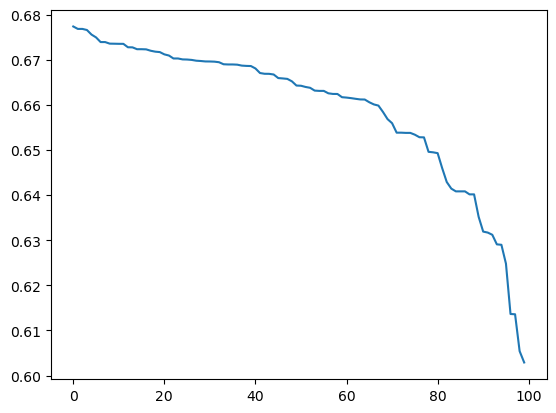

In [7]:
# Graph the search results. Make the index the rank of the score
# another column for the mean test score
rand_search_results = pd.DataFrame(rand_search.cv_results_)
rand_search_results['rank_test_score'] = rand_search_results['rank_test_score']
rand_search_results['mean_test_score'] = rand_search_results['mean_test_score']
rand_search_results = rand_search_results.sort_values(by='rank_test_score', ascending=True)
rand_search_results = rand_search_results.reset_index(drop=True)
rand_search_results['mean_test_score'].plot()

In [8]:
# What are the grid search params for the top 5 scores?
rand_search_results.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_importance_type,...,param_early_stopping_rounds,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.123675,0.010687,0.002316,0.000612,0.7,40,20,2,0.1,total_gain,...,20,"{'subsample': 0.7, 'n_estimators': 40, 'min_ch...",0.671894,0.671299,0.673589,0.672593,0.697453,0.677366,0.010073,1
1,0.161041,0.016370,0.003757,0.001088,0.7,40,20,3,0.1,total_gain,...,50,"{'subsample': 0.7, 'n_estimators': 40, 'min_ch...",0.662696,0.675466,0.669159,0.679016,0.697790,0.676825,0.011871,2
2,0.194563,0.010387,0.002905,0.001536,0.7,50,20,3,0.1,total_gain,...,50,"{'subsample': 0.7, 'n_estimators': 50, 'min_ch...",0.662696,0.675466,0.669159,0.679016,0.697790,0.676825,0.011871,2
3,0.159233,0.004190,0.002667,0.001181,0.5,50,50,3,0.1,total_gain,...,50,"{'subsample': 0.5, 'n_estimators': 50, 'min_ch...",0.673370,0.674361,0.675851,0.664975,0.694360,0.676583,0.009660,4
4,0.172016,0.008582,0.002638,0.000647,0.7,50,100,2,0.1,total_gain,...,50,"{'subsample': 0.7, 'n_estimators': 50, 'min_ch...",0.667086,0.672936,0.671043,0.670555,0.696243,0.675573,0.010507,5


In [9]:
# save the json of the best model
best_model = rand_search.best_estimator_
best_model.save_model(
    os.path.join(module_path, 'models', 'best_random_xgb_model.json')
)

In [10]:
# What is the score on the holdout set?
best_model.score(X_holdout, y_holdout)

0.6176470588235294

In [11]:
holdout_df.loc[:, 'preds'] = best_model.predict_proba(X_holdout)[:, 1]

In [12]:
# Show the predictions for the holdout set
results_df = holdout_df[
    ['game_id', 'week', 'target_team', 'opp_team', 'target_win', 'preds']
].copy()
results_df.sort_values(by='game_id', inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,game_id,week,target_team,opp_team,target_win,preds
0,2023_01_ARI_WAS,1,ARI,WAS,0,0.445594
1,2023_01_ARI_WAS,1,WAS,ARI,1,0.547685
2,2023_01_BUF_NYJ,1,NYJ,BUF,1,0.411414
3,2023_01_BUF_NYJ,1,BUF,NYJ,0,0.572103
4,2023_01_CAR_ATL,1,ATL,CAR,1,0.558682
...,...,...,...,...,...,...
539,2023_18_PIT_BAL,18,BAL,PIT,0,0.675391
540,2023_18_SEA_ARI,18,ARI,SEA,0,0.417984
541,2023_18_SEA_ARI,18,SEA,ARI,1,0.627901
542,2023_18_TB_CAR,18,CAR,TB,0,0.356982


week
1     0.589844
2     0.410156
3     0.570312
4     0.953125
5     0.423469
6     0.733333
7     0.313609
8     0.691406
9     0.872449
10    0.617347
11    0.846939
12    0.566406
13    0.745562
14    0.471111
15    0.742188
16    0.632812
17    0.769531
18    0.589844
dtype: float64

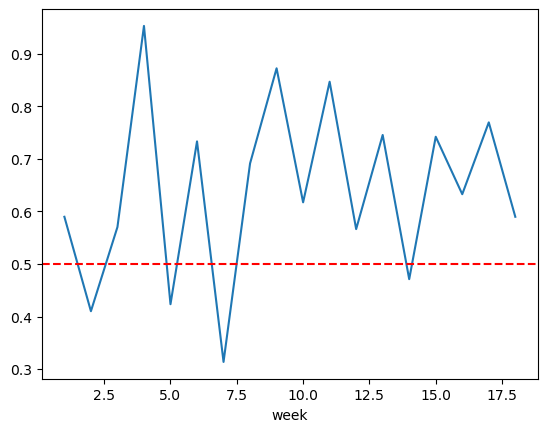

In [13]:
# get the AUROC score by week
weekly_scores = holdout_df.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

In [14]:
# for each game_id, only keep the higher prediction
higher_preds = holdout_df.groupby('game_id').apply(
    lambda x: x.loc[x['preds'].idxmax(), :],
    include_groups=False
)
higher_preds.reset_index(drop=True, inplace=True)

week
1     0.523810
2     0.444444
3     0.460317
4     0.857143
5     0.644444
6     0.600000
7     0.375000
8     0.509091
9     0.625000
10    0.466667
11    0.875000
12    0.254545
13    0.500000
14    0.703704
15    0.437500
16    0.483333
17    0.672727
18    0.539683
dtype: float64

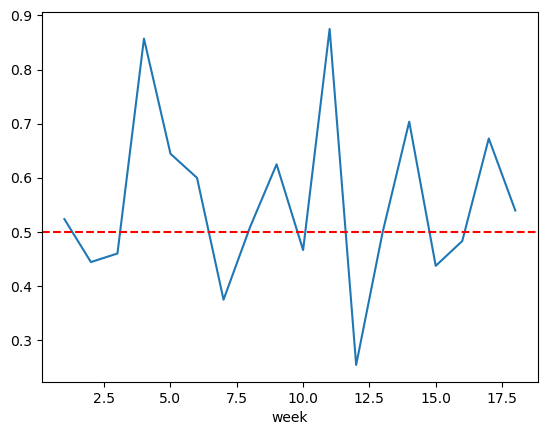

In [15]:
# get the AUROC score by week
weekly_scores = higher_preds.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores